# Lab05 - First Classification by using KNN
#### Date: 4/20/2026
##### Programmmer: Arsilbhai vahora


In [1]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# step 1: load and understand your dataset

from sklearn.datasets import load_digits
digits = load_digits()
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 5620
    :Number of Attributes: 64
    :Attribute Information: 8x8 image of integer pixels in the range 0..16.
    :Missing Attribute Values: None
    :Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
    :Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each blo

In [3]:
data = digits.data
print(data.shape)
data[0:3]

(1797, 64)


array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
         9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
        15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
         0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
        16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.],
       [ 0.,  0.,  0.,  4., 15., 12.,  0.,  0.,  0.,  0.,  3., 16., 15.,
        14.,  0.,  0.,  0.,  0.,  8., 13.,  8., 16.,  0.,  0.,  0.,  0.,
         1.,  6., 15., 11.,  0.,  0.,  0.,  1.,  8., 13., 15.,  1.,  0.,
         0.,  0.,  9., 16., 16.,  5.,  0.,  0.,  0.,  0.,  

In [4]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [5]:
target = digits.target
print(target.shape)
target[0:3]

(1797,)


array([0, 1, 2])

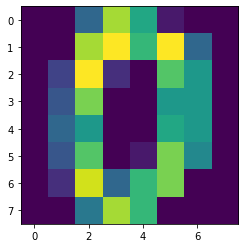

In [6]:
# Step 2: Exploreing data and visualization

image = plt.imshow(digits.images[0])

<BarContainer object of 10 artists>

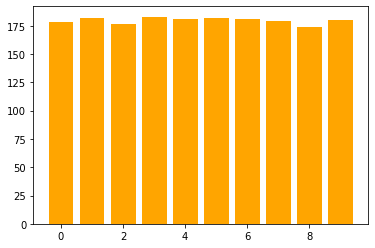

In [7]:
number, count = np.unique(digits.target, return_counts = True)

plt.bar(number,count,color='orange')

# Lab06
# Name
# Date: 4-27-2026

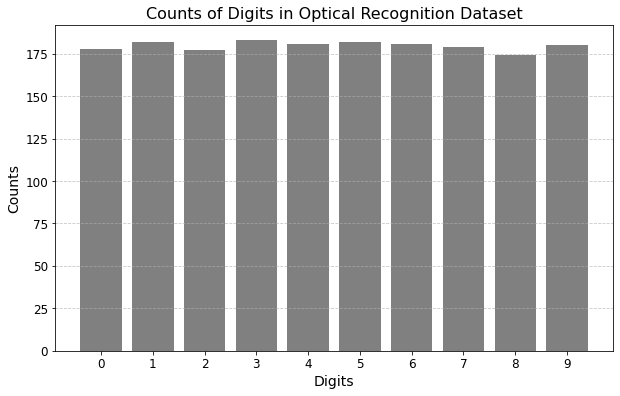

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import numpy as np

# Load the digits dataset
digits = load_digits()

# Get the target labels
targets = digits.target

# Count the occurrences of each digit
unique, counts = np.unique(targets, return_counts=True)

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(unique, counts, color='grey')
plt.xticks(unique, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Digits', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title('Counts of Digits in Optical Recognition Dataset', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the chart
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state = 11, test_size =0.2)

In [10]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1437, 64)
(360, 64)
(1437,)
(360,)


In [11]:

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X = X_train, y = y_train)

KNeighborsClassifier()

In [12]:
predicted = knn.predict(X = X_test)

predicted

array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 5, 6, 9, 6,
       0, 6, 9, 3, 2, 1, 8, 1, 7, 0, 4, 4, 1, 5, 3, 0, 5, 7, 3, 9, 6, 5,
       5, 8, 8, 1, 1, 2, 4, 8, 5, 6, 9, 2, 1, 8, 5, 3, 2, 7, 9, 6, 3, 7,
       4, 2, 0, 1, 0, 2, 7, 3, 5, 1, 8, 7, 7, 2, 0, 6, 6, 4, 6, 8, 3, 7,
       4, 1, 9, 3, 5, 4, 0, 3, 1, 3, 3, 1, 2, 8, 5, 0, 1, 7, 2, 1, 3, 3,
       7, 4, 0, 2, 9, 0, 4, 2, 5, 6, 1, 2, 6, 1, 8, 6, 0, 2, 6, 2, 6, 1,
       9, 4, 8, 0, 4, 0, 2, 3, 4, 4, 1, 7, 4, 7, 2, 0, 3, 7, 8, 8, 7, 5,
       4, 3, 5, 4, 9, 1, 3, 8, 8, 1, 1, 6, 7, 3, 3, 9, 9, 0, 6, 1, 0, 1,
       0, 7, 6, 1, 5, 9, 0, 2, 2, 8, 6, 8, 3, 2, 9, 2, 9, 3, 0, 1, 2, 7,
       4, 9, 9, 7, 9, 3, 2, 7, 2, 6, 9, 8, 0, 2, 6, 3, 4, 2, 7, 6, 6, 7,
       7, 6, 0, 7, 6, 6, 0, 7, 1, 4, 4, 1, 0, 9, 4, 0, 4, 2, 4, 6, 5, 3,
       8, 4, 1, 3, 9, 8, 3, 8, 9, 4, 2, 0, 4, 9, 2, 3, 5, 0, 8, 2, 5, 4,
       7, 5, 5, 1, 0, 2, 9, 0, 7, 7, 6, 2, 1, 5, 4, 1, 0, 5, 1, 6, 5, 4,
       8, 7, 5, 9, 0, 2, 2, 3, 4, 4, 8, 8, 8, 5, 3,

In [13]:
expected = y_test
expected

array([0, 4, 9, 9, 3, 1, 4, 1, 5, 0, 4, 9, 4, 1, 5, 3, 3, 8, 3, 6, 9, 6,
       0, 6, 9, 3, 2, 1, 8, 1, 7, 0, 4, 4, 1, 5, 3, 0, 5, 7, 3, 9, 6, 5,
       5, 8, 8, 1, 1, 2, 4, 9, 5, 6, 9, 2, 1, 8, 5, 3, 2, 7, 9, 6, 3, 7,
       4, 2, 0, 1, 0, 2, 7, 3, 5, 1, 8, 7, 7, 2, 0, 6, 6, 4, 6, 8, 3, 7,
       4, 1, 9, 3, 5, 4, 0, 3, 1, 3, 3, 1, 2, 8, 5, 0, 1, 7, 2, 1, 3, 3,
       7, 4, 0, 2, 9, 0, 4, 2, 5, 6, 1, 2, 6, 1, 8, 6, 0, 2, 6, 2, 6, 1,
       9, 4, 8, 0, 4, 0, 2, 3, 4, 4, 1, 7, 9, 7, 2, 0, 3, 7, 8, 8, 3, 5,
       4, 3, 5, 4, 9, 1, 3, 8, 8, 1, 1, 6, 7, 3, 3, 9, 9, 0, 6, 1, 0, 1,
       0, 7, 6, 1, 5, 9, 0, 2, 2, 8, 6, 8, 3, 2, 9, 2, 9, 3, 0, 1, 2, 7,
       4, 9, 9, 4, 9, 3, 2, 7, 2, 6, 9, 8, 0, 2, 6, 3, 4, 2, 7, 6, 6, 7,
       7, 6, 0, 7, 6, 6, 0, 7, 1, 4, 4, 1, 0, 9, 4, 0, 4, 2, 4, 6, 5, 3,
       8, 4, 1, 3, 9, 8, 3, 8, 9, 4, 2, 0, 4, 9, 2, 3, 5, 0, 8, 2, 5, 4,
       7, 5, 5, 1, 0, 2, 9, 0, 7, 7, 6, 2, 1, 5, 4, 1, 0, 5, 1, 6, 5, 4,
       8, 7, 5, 9, 0, 2, 2, 3, 4, 4, 8, 8, 8, 5, 3,

In [14]:
print(predicted[:30])
print(expected[:30])

[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 5 6 9 6 0 6 9 3 2 1 8 1]
[0 4 9 9 3 1 4 1 5 0 4 9 4 1 5 3 3 8 3 6 9 6 0 6 9 3 2 1 8 1]


In [15]:
wrong = []
for p, e in zip (predicted, expected ):
    if p != e:
        wrong.append((p,e))

print(wrong)

[(5, 3), (8, 9), (4, 9), (7, 3), (7, 4)]


# Lab07 - Classification Evalution
# Arsilbhai vahora
# 4-29-2026

In [20]:
accuracy = (len(predicted) - len(wrong))/len(predicted)
print(accuracy)
print(format(accuracy, '.2%'))
print(f'{accuracy:.2%}')

0.9861111111111112
98.61%
98.61%


In [21]:
accuracy = knn.score( X_test,y_test)
print(accuracy)

0.9861111111111112


In [22]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_true = expected, y_pred = predicted)
print(matrix)


[[38  0  0  0  0  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 39  0  0  0  0  0  0  0]
 [ 0  0  0 39  0  1  0  1  0  0]
 [ 0  0  0  0 40  0  0  1  0  0]
 [ 0  0  0  0  0 27  0  0  0  0]
 [ 0  0  0  0  0  0 30  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  0  0  0  0  0  0  0 34  0]
 [ 0  0  0  0  1  0  0  0  1 35]]


In [23]:
from sklearn.metrics import classification_report

report = classification_report(expected,predicted)
print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        39
           3       1.00      0.95      0.97        41
           4       0.98      0.98      0.98        41
           5       0.96      1.00      0.98        27
           6       1.00      1.00      1.00        30
           7       0.95      1.00      0.97        36
           8       0.97      1.00      0.99        34
           9       1.00      0.95      0.97        37

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



<AxesSubplot:>

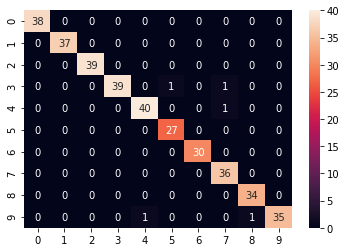

In [24]:
matrix_df = pd.DataFrame(matrix)

import seaborn as sns
sns.heatmap(matrix_df, annot = True)